# Notebook1：DAS定位开发主流程

本notebook用于单样本开发与批处理验证。每一步都会产出中间结果、图表和指标。

## 1. 初始化
### 1.1 导入库与函数

In [148]:
#  VSCode/Jupyter  src 
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / "src").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "src").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

from src.das_localization.io_utils import read_phase_bin_file, infer_points_per_frame, infer_sample_rate_hz
from src.das_localization.localization import LocalizeConfig, localize_single_event, preprocess_data
from src.das_localization.tdoa import select_reference_channel, estimate_delays, apply_physical_tau_window
from src.das_localization.batch import run_batch

# 
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
print(f"PROJECT_ROOT={PROJECT_ROOT}")

%matplotlib inline

PROJECT_ROOT=E:\codes\ZZ-BK


### 1.2 参数区

In [149]:
# 
DATA_FILE = r"E:\codes\ZZ-BK\data\eDAS_loc\eDAS-100000Hz-0028pt-20260326T161851.332.bin"
OUTPUT_ROOT = Path(r"E:\codes\ZZ-BK\outputs\das_localization")
(OUTPUT_ROOT / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "intermediate").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "logs").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "metrics").mkdir(parents=True, exist_ok=True)

# 
FS = 100000.0
DX = 5
N_CHANNELS = 32

# 
DO_DEMEAN = True
DO_HIGHPASS = True
HP_CUTOFF = 1000.0
HP_ORDER = 4
DO_BANDPASS = False
BP_LOWCUT = 120.0
BP_HIGHCUT = 800.0
BP_ORDER = 4
NORMALIZE = True

# TDOA 
REF_MODE = "best_snr"      # best_snr | fixed
REF_CH = 15
DELAY_METHOD = "gcc_phat"  # gcc_phat | ncc | fft_xcorr
MAX_TAU_SEC = 0.02  # 最大TDOA对应的时间窗口，基于麦克风阵列几何和声速计算得到，单位为秒
PSR_TH = 4.0    # 峰值与次峰的比值阈值，基于经验设置，较高的PSR可以过滤掉弱相关或多径引起的次峰，但过高可能会丢失一些有效事件
N_VALID_MIN = 8

# 
VELOCITY = 343.0
X_BOUNDS = (-20.0, 120.0)
Z_BOUNDS = (0.1, 5.0)
FIT_SOLVER = "least_squares"  # least_squares | robust
ROBUST_LOSS = "huber"
USE_RANSAC = True
RANSAC_ITERS = 200
RANSAC_RESID_TH = 8e-4
RMSE_TH = 1e-3
CONF_TH = 0.6

# 
cfg = LocalizeConfig(
    fs=FS, dx=DX, velocity=VELOCITY,
    ref_mode=REF_MODE, ref_ch=REF_CH,
    delay_method=DELAY_METHOD, max_tau_sec=MAX_TAU_SEC,
    psr_th=PSR_TH, n_valid_min=N_VALID_MIN,
    fit_model="hyperbola", fit_solver=FIT_SOLVER,
    robust_loss=ROBUST_LOSS, use_ransac=USE_RANSAC,
    ransac_iters=RANSAC_ITERS, ransac_resid_th=RANSAC_RESID_TH,
    x_bounds=X_BOUNDS, z_bounds=Z_BOUNDS,
    do_demean=DO_DEMEAN, do_highpass=DO_HIGHPASS,
    hp_cutoff=HP_CUTOFF, hp_order=HP_ORDER,
    do_bandpass=DO_BANDPASS, bp_lowcut=BP_LOWCUT, bp_highcut=BP_HIGHCUT, bp_order=BP_ORDER,
    normalize=NORMALIZE, rmse_th=RMSE_TH, conf_th=CONF_TH,
)
print(cfg)

LocalizeConfig(fs=100000.0, dx=5, velocity=343.0, ref_mode='best_snr', ref_ch=15, delay_method='gcc_phat', max_tau_sec=0.02, psr_th=4.0, n_valid_min=8, fit_model='hyperbola', fit_solver='least_squares', robust_loss='huber', use_ransac=True, ransac_iters=200, ransac_resid_th=0.0008, x_bounds=(-20.0, 120.0), z_bounds=(0.1, 5.0), do_demean=True, do_highpass=True, hp_cutoff=1000.0, hp_order=4, do_bandpass=False, bp_lowcut=120.0, bp_highcut=800.0, bp_order=4, normalize=True, rmse_th=0.001, conf_th=0.6)


## 2. 数据加载与查看
### 2.1 读取数据

In [150]:
# bin
points = infer_points_per_frame(DATA_FILE)
fs_from_name = infer_sample_rate_hz(DATA_FILE)
print(f": points={points}, fs={fs_from_name}")

data = read_phase_bin_file(DATA_FILE, points_per_frame=points)
print("shape:", data.shape)
if data.shape[1] != N_CHANNELS:
    print(f": N_CHANNELS={N_CHANNELS}, ={data.shape[1]}")
print(data)
# 
meta = {
    "data_shape": tuple(map(int, data.shape)),
    "points_per_frame": int(points),
    "fs_from_name": fs_from_name,
}
with open(OUTPUT_ROOT / "logs" / "notebook1_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

: points=28, fs=100000.0
shape: (12780, 28)
: N_CHANNELS=32, =28
[[-1.79001846e-01  5.19651850e-02  2.08723631e-01 ... -2.07343006e+00
   2.72289899e-02 -1.73038314e+00]
 [-2.08531877e-01  6.42374059e-02  2.44485649e-01 ... -2.10612402e+00
   2.04217425e-02 -1.72012433e+00]
 [-1.94629752e-01  4.83218695e-02  2.76124968e-01 ... -2.13699633e+00
   5.76219118e-02 -1.72280887e+00]
 ...
 [-7.86860283e-01 -7.34415715e-02  3.47073745e-02 ...  1.98138840e+00
   1.90411176e-01  2.13229837e-01]
 [-7.04022793e-01 -4.95682669e-02 -4.79383626e-04 ...  1.97151310e+00
   1.77084311e-01  1.76317298e-01]
 [-7.64904513e-01 -2.93382779e-02 -2.10928795e-03 ...  1.97036258e+00
   1.55991432e-01  2.09394768e-01]]


### 2.2 数据预处理

In [151]:
# 2.2 Preprocessing implementation + 2.3 visualization (time-space / multi-channel waveform / PSD)
proc = preprocess_data(data, cfg)
print("proc shape:", proc.shape)
print("proc dtype:", proc.dtype)
print("proc min/max:", proc.min(), proc.max())
print(proc)

proc shape: (12780, 28)
proc dtype: float64
proc min/max: -14.590828891594636 14.665893311224913
[[-0.17977815  0.089975   -0.18370491 ...  0.12791697  0.02208567
  -0.00283795]
 [-1.18977235  0.57034802  1.01278893 ... -0.47984784 -0.24857979
   0.24628324]
 [-0.63663236 -0.08770057  2.07104588 ... -1.05184613  0.89122771
   0.17805583]
 ...
 [-0.7988304  -1.55025098  1.42056255 ...  0.60478737  1.05654209
   0.2333592 ]
 [ 2.17907288 -0.60202575  0.24449003 ...  0.35451918  0.7036614
  -0.70258842]
 [-0.01430095  0.19661683  0.18980796 ...  0.26873331  0.10225378
   0.07649735]]


In [152]:
# 2.2 Trackable preprocessing steps for subsection documentation
preproc_steps = {}
x = np.asarray(data, dtype=np.float64)
preproc_steps["raw"] = x
if cfg.do_demean:
    x = x - np.mean(x, axis=0, keepdims=True)
    preproc_steps["demean"] = x
if cfg.do_highpass:
    b, a = signal.butter(cfg.hp_order, cfg.hp_cutoff / (cfg.fs / 2.0), btype="high")
    x = signal.filtfilt(b, a, x, axis=0)
    preproc_steps["highpass"] = x
if cfg.do_bandpass:
    b, a = signal.butter(
        cfg.bp_order,
        [cfg.bp_lowcut / (cfg.fs / 2.0), cfg.bp_highcut / (cfg.fs / 2.0)],
        btype="band",
    )
    x = signal.filtfilt(b, a, x, axis=0)
    preproc_steps["bandpass"] = x
if cfg.normalize:
    ch_std = np.std(x, axis=0, keepdims=True)
    x = x / np.maximum(ch_std, 1e-12)
    preproc_steps["normalize"] = x

# Consistency check against preprocess_data output
preproc_diff = float(np.max(np.abs(x - proc)))
print(f"max|manual-preprocess - preprocess_data| = {preproc_diff:.3e}")

max|manual-preprocess - preprocess_data| = 0.000e+00


### 2.3 绘图查看
#### 2.3.1 Time-space plot (x: time, y: distance)

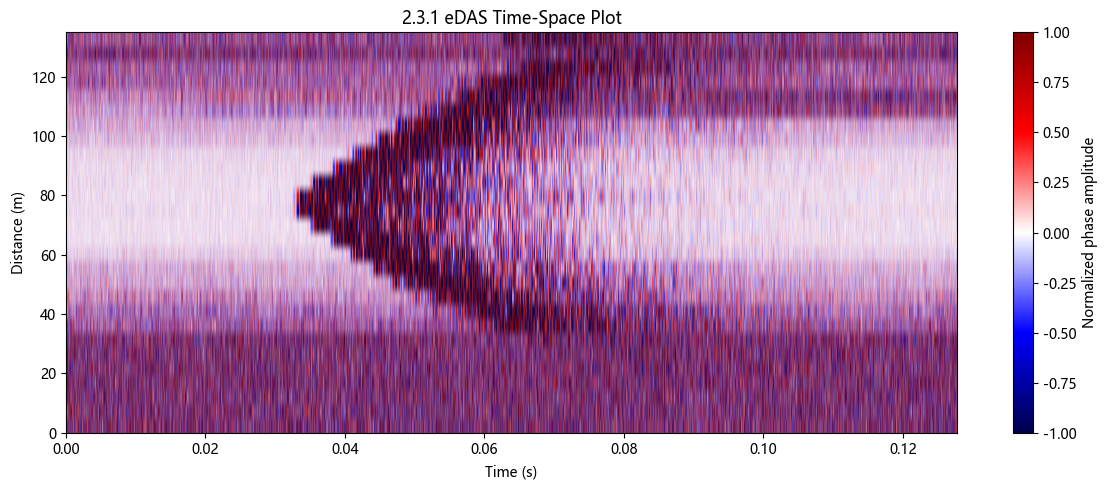

In [153]:
# 2.3.1 Time-space plot (x: time, y: distance)
t = np.arange(proc.shape[0]) / FS
dist_m = np.arange(proc.shape[1]) * DX

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    proc.T,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], dist_m[0], dist_m[-1]],
    cmap="seismic",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Distance (m)")
ax.set_title("2.3.1 eDAS Time-Space Plot")
im.set_clim(-1, 1)
cb = fig.colorbar(im, ax=ax)
cb.set_label("Normalized phase amplitude")
# cb.set_clim(-1, 1)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_231_time_space.png", dpi=160)


#### 2.3.2 Multi-channel time-domain waveforms

In [193]:
# 2.3.2 Multi-channel time-domain waveforms
show_ch = np.unique(
    np.clip(
        np.array([0, proc.shape[1] // 4, proc.shape[1] // 2, 3 * proc.shape[1] // 4, proc.shape[1] - 1]),
        0,
        proc.shape[1] - 1,
    )
)

fig, axes = plt.subplots(len(show_ch), 1, figsize=(12, 8), sharex=True)
if len(show_ch) == 1:
    axes = [axes]
for i, ch in enumerate(show_ch):
    axes[i].plot(t, proc[:, ch], lw=0.9, color="#0f5ea8", label=f"CH{ch}")
    axes[i].set_ylabel(f"CH{ch}", fontsize=20)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='y', which='major', labelsize=20)
    # y轴保留2位小数
    axes[i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    axes[i].set_ylim()
    # axes[i].legend(fontsize=20)
axes[-1].set_xlabel("Time (s)", fontsize=20)
axes[-1].tick_params(axis='x', which='major', labelsize=20)
fig.suptitle("2.3.2 Multi-channel Time-domain Waveforms")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_232_multichannel_time.png", dpi=160)

# 2.3.3 Multi-channel PSD
fig, ax = plt.subplots(figsize=(12, 5))
for ch in show_ch:
    f_psd, pxx = signal.welch(proc[:, ch], fs=FS, nperseg=min(2048, proc.shape[0]))
    ax.plot(f_psd, 10 * np.log10(pxx + 1e-20), lw=1.0, label=f"Ch{ch}")
ax.set_xlim(0, FS / 2)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB/Hz)")
ax.set_title("2.3.3 Multi-channel PSD")
ax.grid(alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_233_multichannel_psd.png", dpi=160)



## 3. 参考通道选择（best_snr vs fixed 对比）

In [155]:
#  vs 
ref_best = select_reference_channel(proc, mode="best_snr", fixed_idx=REF_CH)
ref_fixed = select_reference_channel(proc, mode="fixed", fixed_idx=REF_CH)
print("best_snr:", ref_best)
print("fixed:", ref_fixed)

best_snr: 16
fixed: 15


## 4. GCC-PHAT 计算与峰值提取；亚采样插值验证

### 4.1 Cross-correlation and peak extraction


In [176]:
# 4.1 Cross-correlation and peak extraction

# Use delay estimator for downstream localization compatibility
ref_idx = select_reference_channel(proc, mode=REF_MODE, fixed_idx=REF_CH)
delay_res = estimate_delays(
    proc,
    fs=FS,
    ref_idx=ref_idx,
    method=DELAY_METHOD,
    max_tau_sec=MAX_TAU_SEC,
    psr_th=PSR_TH,
)
print("method:", delay_res.method, "ref_idx:", delay_res.ref_idx)
print("first 5 estimator TDOA(s):", delay_res.delays[:5])

# Per-channel cross-correlation against the reference channel
max_lag = int(MAX_TAU_SEC * FS)
lag_idx = np.arange(-max_lag, max_lag + 1)
lag_t = lag_idx / FS

ref_sig = proc[:, ref_idx]
xcorr_mat = np.zeros((proc.shape[1], lag_idx.size), dtype=np.float64)
peak_tau_all = np.zeros(proc.shape[1], dtype=np.float64)
peak_val_all = np.zeros(proc.shape[1], dtype=np.float64)

for ch in range(proc.shape[1]):
    sig = proc[:, ch]
    cc_full = signal.correlate(sig, ref_sig, mode="full", method="fft")
    lags_full = np.arange(-(proc.shape[0] - 1), proc.shape[0])
    mask = (lags_full >= -max_lag) & (lags_full <= max_lag)
    cc = cc_full[mask]

    # Global comparability across channels for plotting and QC
    norm = (np.linalg.norm(sig) * np.linalg.norm(ref_sig) + 1e-12)
    cc = cc / norm
    xcorr_mat[ch, :] = cc

    # Peak extraction for cross-correlation
    if ch == ref_idx:
        pk = int(np.argmin(np.abs(lag_t)))
        peak_tau_all[ch] = 0.0
        peak_val_all[ch] = np.abs(cc[pk])
    else:
        pk = int(np.argmax(np.abs(cc)))
        peak_tau_all[ch] = lag_t[pk]
        peak_val_all[ch] = np.abs(cc[pk])



method: gcc_phat ref_idx: 16
first 5 estimator TDOA(s): [-0.00050998  0.00042953 -0.00016989 -0.00017028  0.00491   ]


In [177]:
# Quality control: high raw-data SNR + strong cross-correlation peak + valid/physical constraints
raw_power = np.asarray(proc, dtype=np.float64) ** 2

p_hi = np.quantile(raw_power, 0.90, axis=0)
p_lo = np.quantile(raw_power, 0.10, axis=0)
raw_snr_proxy = (p_hi + 1e-12) / (p_lo + 1e-12)

snr_th = float(np.quantile(raw_snr_proxy, 0.50))
peak_th = float(np.quantile(peak_val_all, 0.50))
physical_mask = apply_physical_tau_window(peak_tau_all, MAX_TAU_SEC)

quality_mask = (
    (raw_snr_proxy >= snr_th)
    & (peak_val_all >= peak_th)
    & (delay_res.psr >= PSR_TH)
    & physical_mask
)
quality_mask[ref_idx] = True

# Keep only selected peaks for visualization and follow-up
peak_tau = np.where(quality_mask, peak_tau_all, np.nan)
peak_val = np.where(quality_mask, peak_val_all, np.nan)

print(f"QC thresholds: snr_th={snr_th:.3f}, peak_th={peak_th:.3f}, psr_th={PSR_TH:.3f}")
print(f"Selected channels: {int(np.sum(quality_mask))}/{proc.shape[1]}")



QC thresholds: snr_th=378.949, peak_th=0.164, psr_th=4.000
Selected channels: 14/28


### 4.2 Full-channel cross-correlation visualization


In [173]:
%matplotlib qt

In [175]:
# 4.2 Vertical-curve view: x=distance, y=delay; plot all cross-correlation curves with one global scale
x_dist = np.arange(proc.shape[1]) * DX

global_absmax = float(np.max(np.abs(xcorr_mat))) + 1e-12
x_scale = 0.42 * DX / global_absmax
amp_for_plot = xcorr_mat * x_scale

fig, ax = plt.subplots(figsize=(12, 6))
for ch in range(proc.shape[1]):
    x_curve = x_dist[ch] + amp_for_plot[ch]
    color = "#1f77b4" if quality_mask[ch] else "#b8b8b8"
    alpha = 0.75 if quality_mask[ch] else 0.45
    ax.plot(x_curve, lag_t * 1e3, color=color, lw=0.8, alpha=alpha)

sel = np.where(quality_mask)[0]
ax.scatter(x_dist[sel], peak_tau[sel] * 1e3, s=20, c="red", label="Selected peaks")
ax.plot(x_dist[sel], peak_tau[sel] * 1e3, "r-", lw=1.2, alpha=0.9, label="Selected peak linkage")
ax.axhline(0.0, ls="--", lw=0.8, c="k", alpha=0.5)
ax.set_xlabel("Distance (m)", fontsize=20)
ax.set_ylabel("Delay (ms)", fontsize=20)
ax.set_title("4.2 Full-channel Cross-correlation Curves (Global Scale) + QC Peaks")
ax.grid(alpha=0.25)
ax.legend(fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_42_xcorr_vertical_curves.png", dpi=160)



### 4.3 Cross-correlation heatmap


saved: E:\codes\ZZ-BK\outputs\das_localization\intermediate\nb1_xcorr_peaks.csv


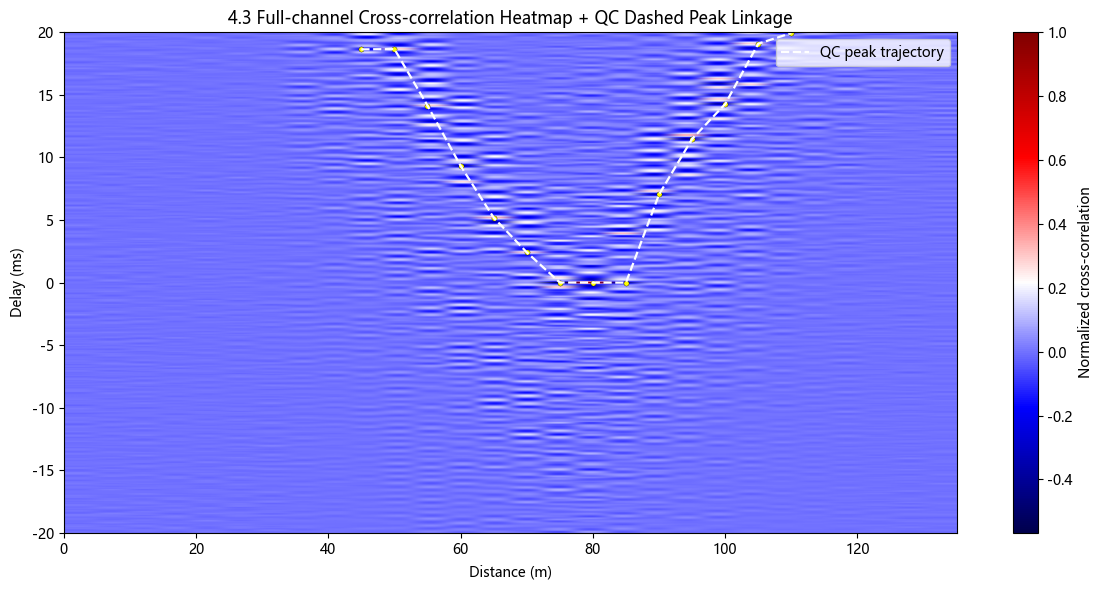

In [159]:
# 4.3 Heatmap view: x=distance, y=delay, color=cross-correlation value; mark QC-selected peaks
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    xcorr_mat.T,
    aspect="auto",
    origin="lower",
    extent=[x_dist[0], x_dist[-1], lag_t[0] * 1e3, lag_t[-1] * 1e3],
    cmap="seismic",
)

sel = np.where(quality_mask)[0]
ax.plot(x_dist[sel], peak_tau[sel] * 1e3, "w--", lw=1.6, label="QC peak trajectory")
ax.scatter(x_dist[sel], peak_tau[sel] * 1e3, s=14, c="yellow", edgecolors="k", linewidths=0.25)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Delay (ms)")
ax.set_title("4.3 Full-channel Cross-correlation Heatmap + QC Dashed Peak Linkage")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Normalized cross-correlation")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_43_xcorr_heatmap.png", dpi=160)

# Export subsection 4.1 peak-extraction table with QC flags
xcorr_peak_df = pd.DataFrame({
    "channel": np.arange(proc.shape[1], dtype=int),
    "distance_m": x_dist,
    "raw_snr_proxy": raw_snr_proxy,
    "peak_tau_all_s": peak_tau_all,
    "peak_tau_qc_s": peak_tau,
    "peak_tau_qc_ms": peak_tau * 1e3,
    "peak_xcorr_all": peak_val_all,
    "peak_xcorr_qc": peak_val,
    "estimator_tdoa_s": delay_res.delays,
    "psr": delay_res.psr,
    "snr_pass": raw_snr_proxy >= snr_th,
    "peak_pass": peak_val_all >= peak_th,
    "psr_pass": delay_res.psr >= PSR_TH,
    "physical_pass": physical_mask,
    "quality_pass": quality_mask,
})
xcorr_peak_df.to_csv(OUTPUT_ROOT / "intermediate" / "nb1_xcorr_peaks.csv", index=False, encoding="utf-8-sig")
print("saved:", OUTPUT_ROOT / "intermediate" / "nb1_xcorr_peaks.csv")



### 4.4 Full-channel auto-correlation visualization


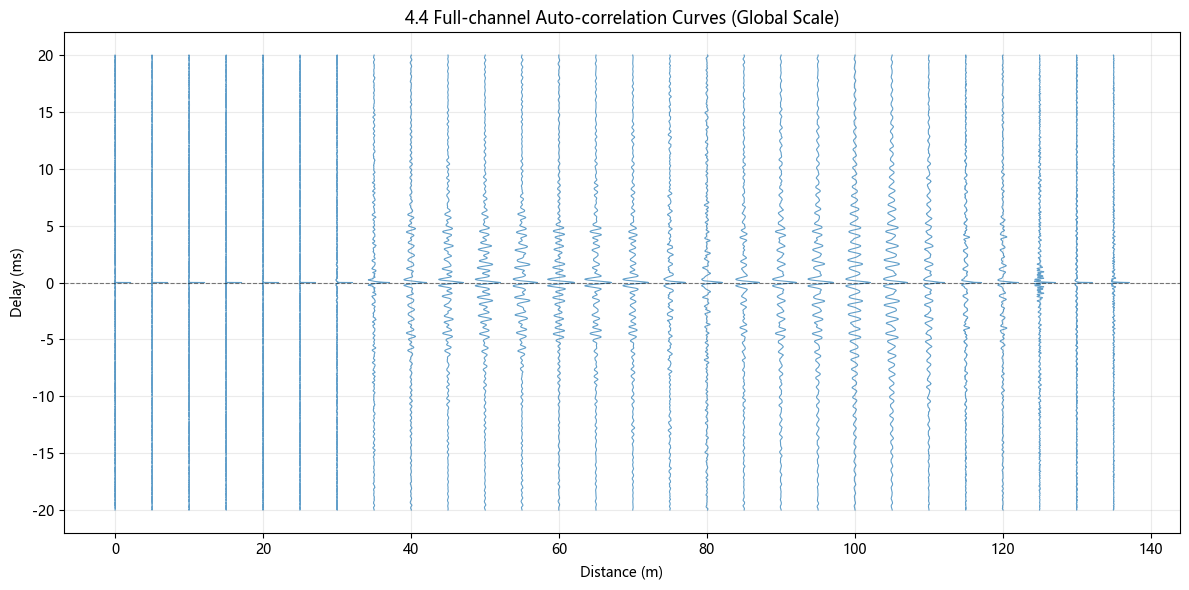

In [160]:
# 4.4 Full-channel auto-correlation curves (all channels)
# Reuse the same lag window as 4.1/4.2 for consistency
acorr_mat = np.zeros((proc.shape[1], lag_idx.size), dtype=np.float64)

for ch in range(proc.shape[1]):
    sig = proc[:, ch]
    ac_full = signal.correlate(sig, sig, mode="full", method="fft")
    ac_lags_full = np.arange(-(proc.shape[0] - 1), proc.shape[0])
    ac_mask = (ac_lags_full >= -max_lag) & (ac_lags_full <= max_lag)
    ac = ac_full[ac_mask]

    # Normalize by channel energy for comparability; plotting still uses one global scale
    ac = ac / (np.linalg.norm(sig) ** 2 + 1e-12)
    acorr_mat[ch, :] = ac

ac_global_absmax = float(np.max(np.abs(acorr_mat))) + 1e-12
ac_x_scale = 0.42 * DX / ac_global_absmax
ac_amp_for_plot = acorr_mat * ac_x_scale

fig, ax = plt.subplots(figsize=(12, 6))
for ch in range(proc.shape[1]):
    x_curve = x_dist[ch] + ac_amp_for_plot[ch]
    ax.plot(x_curve, lag_t * 1e3, color="#1f77b4", lw=0.8, alpha=0.7)

ax.axhline(0.0, ls="--", lw=0.8, c="k", alpha=0.5)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Delay (ms)")
ax.set_title("4.4 Full-channel Auto-correlation Curves (Global Scale)")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_44_acorr_vertical_curves.png", dpi=160)



## 5. PSR 与物理时延窗筛选；产出 tdoa + quality metrics

峰旁瓣比PSR：  
- 描述：衡量相关函数主峰相对于旁瓣/次峰的显著性（主峰强度 / 次峰或背景噪声水平）。  
- 含义：PSR 越大，主峰越明显，TDOA 估计越可靠。Notebook 中使用 psr 与 PSR_TH（默认 4.0）做筛选。

峰值相关系数：  
- 描述：信号与参考通道互相关的最大归一化相关值（即峰值相关系数或峰幅值）。  
- 含义：反映两通道之间的相关强度，常与全局阈值（peak_th）比较以剔除弱相关通道。

峰均比（PPR）：  
- 描述：主峰幅值与其他时延样本平均或背景能量的比值（类似 peak-to-average 或 peak-to-mean 指标）。  
- 含义：用于补充 PSR/peak 的判别，衡量主峰相对于整体相关谱的突出程度。

物理时延窗（physical tau window）：  
- 描述：基于阵列几何、通道间距 DX 和声速 VELOCITY 推导的最大合理 TDOA（MAX_TAU_SEC），用于剔除超出物理可能性的估计。  
- 含义：保证保留下来的 TDOA 在物理可达范围内。

最终有效性判据（valid）：  
- 描述：把 raw SNR（或 raw_snr_proxy）、peak、psr 以及物理时延窗的布尔检验综合起来得到 quality/valid 标志；参考通道强制置为有效。  
- 含义：只有同时满足 SNR/peak/PSR/物理约束（且通道数 >= N_VALID_MIN）才被用于定位与后续拟合。

阈值提示：PSR_TH、peak_th、snr_th（在 notebook 中按数据分位自动计算）决定了筛选严格度，需根据数据和应用调整。

### 5.1 质量筛选与结果落盘（tdoa + quality metrics）\n
\n
本小节将 4.1 得到的 TDOA 估计结果进行质量筛选，并输出后续定位所需的中间文件。\n
\n
- 先按物理时延窗 `MAX_TAU_SEC` 过滤不可能的时延；\n
- 再与算法内部有效掩码 `delay_res.valid_mask` 取交集，得到最终 `valid`；\n
- 参考通道强制保留为有效；\n
- 导出 `tdoa_quality_metrics.csv`（每通道 `tdoa_sec / psr / peak / valid`）与 `tdoa.npy`。\n

In [165]:
#  PSR 
physical_mask = apply_physical_tau_window(delay_res.delays, MAX_TAU_SEC)    # 基于物理约束的有效性掩码，确保TDOA估计在合理范围内
valid = delay_res.valid_mask & physical_mask    # 综合考虑TDOA估计的内部有效性掩码和物理约束，得到最终的有效性掩码
valid[delay_res.ref_idx] = True # 确保参考通道的TDOA估计被视为有效，即使它的内部有效性掩码可能为False，因为参考通道的TDOA定义为0且具有物理意义

# 
metrics_df = pd.DataFrame(
    {
        "channel": np.arange(proc.shape[1]),
        "tdoa_sec": delay_res.delays,
        "psr": delay_res.psr,
        "peak": delay_res.peak,
        "valid": valid,
    }
)   # 导出TDOA质量评估表格，包含每个通道的TDOA估计值、PSR、峰值以及最终的有效性标记，供后续分析和定位使用
metrics_df.to_csv(OUTPUT_ROOT / "intermediate" / "tdoa_quality_metrics.csv", index=False, encoding="utf-8-sig")
np.save(OUTPUT_ROOT / "intermediate" / "tdoa.npy", delay_res.delays)
print(metrics_df.head())
print(":", int(valid.sum()))

   channel  tdoa_sec       psr      peak  valid
0        0  -0.00051  5.432506  0.034576   True
1        1   0.00043  4.047566  0.025528   True
2        2  -0.00017  5.036431  0.032030   True
3        3  -0.00017  5.044881  0.032316   True
4        4   0.00491  5.436114  0.034632   True
: 28


### 5.2 绘制筛选前后的多通道互相关曲线图对比

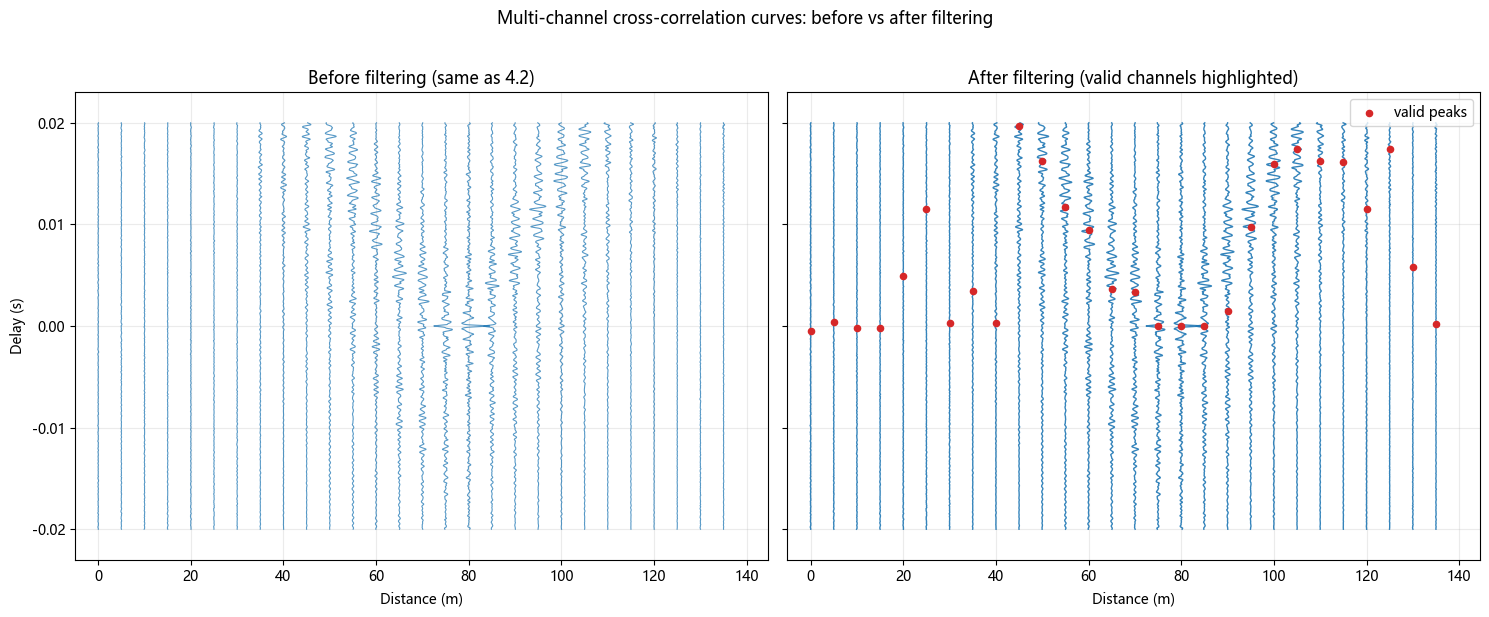

In [169]:
# 5.2 Compare multi-channel xcorr curves: before filter (same as 4.2) vs after filter (valid only)
if "x_dist" not in globals():
    x_dist = np.arange(proc.shape[1]) * DX

# Resolve lag axis robustly to avoid execution-order NameError
if "lag_t" in globals():
    lag_axis = np.asarray(lag_t, dtype=float)
elif "lag_sec" in globals():
    lag_axis = np.asarray(lag_sec, dtype=float)
elif "lag_idx" in globals():
    lag_axis = np.asarray(lag_idx, dtype=float) / float(FS)
else:
    raise NameError("lag axis missing: run section 4.1 first to create lag_t/lag_idx")

scale = float(np.max(np.abs(xcorr_mat))) + 1e-12
offset_span = float(np.max(np.abs(lag_axis))) * 1.15
curve_scale = 0.9 * DX

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Left: before filtering
ax = axes[0]
for ch in range(proc.shape[1]):
    curve = (xcorr_mat[ch] / scale) * curve_scale
    ax.plot(x_dist[ch] + curve, lag_axis, lw=0.8, alpha=0.75, color="tab:blue")
ax.set_title("Before filtering (same as 4.2)")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Delay (s)")
ax.grid(alpha=0.25)

# Right: after filtering (valid highlighted, invalid faded)
ax = axes[1]
for ch in range(proc.shape[1]):
    curve = (xcorr_mat[ch] / scale) * curve_scale
    if bool(valid[ch]):
        ax.plot(x_dist[ch] + curve, lag_axis, lw=1.0, alpha=0.9, color="tab:blue")
    else:
        ax.plot(x_dist[ch] + curve, lag_axis, lw=0.7, alpha=0.25, color="tab:gray")

# Mark selected peak points used for localization
ax.scatter(
    x_dist[valid],
    delay_res.delays[valid],
    s=20,
    c="tab:red",
    label="valid peaks",
    zorder=3,
)
ax.set_title("After filtering (valid channels highlighted)")
ax.set_xlabel("Distance (m)")
ax.grid(alpha=0.25)
ax.legend(loc="best")

for ax in axes:
    ax.set_xlim(x_dist.min() - DX, x_dist.max() + DX + curve_scale)
    ax.set_ylim(-offset_span, offset_span)

fig.suptitle("Multi-channel cross-correlation curves: before vs after filtering", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_xcorr_before_after_filtering.png", dpi=160)
plt.show()


### 5.3 读取 tdoa + quality metrics，并可视化与可辨识性检查\n

In [167]:
# 5.3 Count comparison and mask relationship: 4.1 quality_mask vs 5.1 valid
n_ch = int(proc.shape[1])
n_qc41 = int(np.sum(quality_mask))
n_valid51 = int(np.sum(valid))

only_in_41 = np.where(quality_mask & ~valid)[0]
only_in_51 = np.where(valid & ~quality_mask)[0]
both = np.where(valid & quality_mask)[0]

print("Total channels:", n_ch)
print("4.1 quality_mask selected:", n_qc41)
print("5.1 valid selected:", n_valid51)
print("Intersection (4.1 & 5.1):", int(both.size))
print("Only in 4.1 (quality_mask & ~valid):", int(only_in_41.size), only_in_41.tolist())
print("Only in 5.1 (valid & ~quality_mask):", int(only_in_51.size), only_in_51.tolist())

cmp_df = pd.DataFrame({
    "channel": np.arange(n_ch, dtype=int),
    "quality_mask_41": quality_mask.astype(bool),
    "valid_51": valid.astype(bool),
    "raw_snr_proxy": raw_snr_proxy,
    "peak_val_all": peak_val_all,
    "psr": delay_res.psr,
})
cmp_df["relation"] = np.select(
    [cmp_df["quality_mask_41"] & cmp_df["valid_51"],
     cmp_df["quality_mask_41"] & ~cmp_df["valid_51"],
     ~cmp_df["quality_mask_41"] & cmp_df["valid_51"]],
    ["both", "only_4.1", "only_5.1"],
    default="neither"
)
cmp_path = OUTPUT_ROOT / "intermediate" / "nb1_mask_comparison_41_vs_51.csv"
cmp_df.to_csv(cmp_path, index=False, encoding="utf-8-sig")
print("saved:", cmp_path)


Total channels: 28
4.1 quality_mask selected: 14
5.1 valid selected: 28
Intersection (4.1 & 5.1): 14
Only in 4.1 (quality_mask & ~valid): 0 []
Only in 5.1 (valid & ~quality_mask): 14 [0, 1, 2, 3, 4, 5, 6, 7, 8, 23, 24, 25, 26, 27]
saved: E:\codes\ZZ-BK\outputs\das_localization\intermediate\nb1_mask_comparison_41_vs_51.csv


<!-- 原第6节已并入第5节，保留此单元以减少执行顺序变动 -->\n

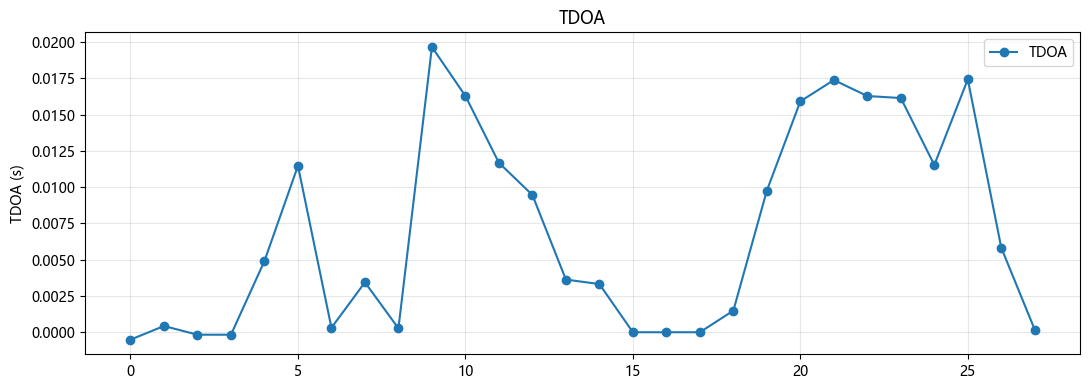

In [168]:
# TDOA
metrics_df = pd.read_csv(OUTPUT_ROOT / "intermediate" / "tdoa_quality_metrics.csv")
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(metrics_df["channel"], metrics_df["tdoa_sec"], "o-", label="TDOA")
ax.scatter(
    metrics_df.loc[~metrics_df["valid"], "channel"],
    metrics_df.loc[~metrics_df["valid"], "tdoa_sec"],
    c="r",
    label="",
)
ax.set_xlabel("")
ax.set_ylabel("TDOA (s)")
ax.set_title("TDOA")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "figures" / "nb1_tdoa_visibility.png", dpi=160)

## 7. 网格粗搜索 + least_squares受约束精修 + RANSAC/robust对比 + 置信度判决

In [170]:
# 
result = localize_single_event(data, cfg)
print(":")
for k in ["source_x", "source_z", "valid_channels", "rmse_tdoa", "confidence", "status", "reason", "ref_idx"]:
    print(f"{k}: {result.get(k)}")

# 
out_result = {
    k: (float(v) if isinstance(v, (np.floating, float)) else v)
    for k, v in result.items()
    if k not in ["tdoa", "psr", "fit"]
}
with open(OUTPUT_ROOT / "metrics" / "single_result.json", "w", encoding="utf-8") as f:
    json.dump(out_result, f, ensure_ascii=False, indent=2)

:
source_x: 53.53287841243373
source_z: 4.999999999999999
valid_channels: 28
rmse_tdoa: 0.06744545582216166
confidence: 0.65
status: rejected
reason: high_fit_rmse
ref_idx: 16


## 8. 误差分析（单样本）

C:\Users\QiGh\AppData\Local\Temp\ipykernel_28876\1734568876.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


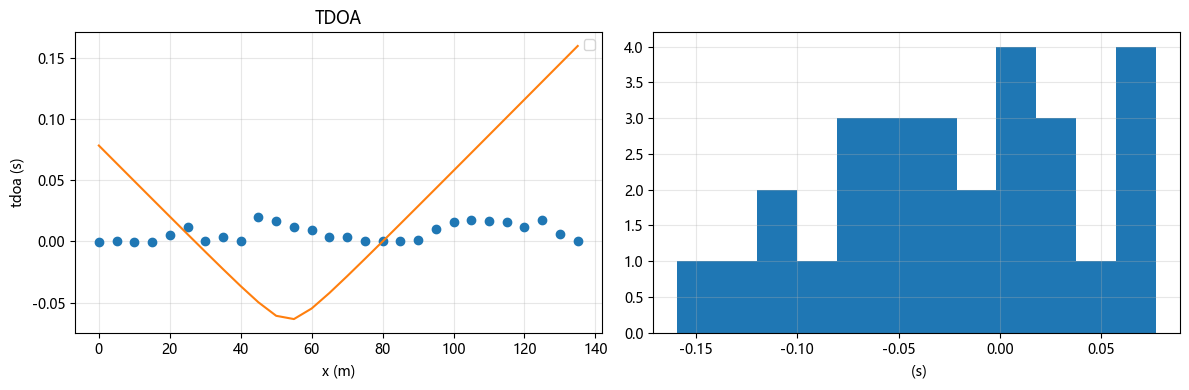

In [172]:
# 
if result.get("fit") and "pred" in result["fit"]:
    valid_idx = metrics_df[metrics_df["valid"]].index.to_numpy()
    xv = valid_idx * DX
    tv = metrics_df.loc[valid_idx, "tdoa_sec"].to_numpy()
    pred = result["fit"]["pred"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(xv, tv, "o", label="")
    axes[0].plot(xv, pred, "-", label="")
    axes[0].set_title("TDOA")
    axes[0].set_xlabel("x (m)")
    axes[0].set_ylabel("tdoa (s)")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    resid = tv - pred
    axes[1].hist(resid, bins=12)
    axes[1].set_title("")
    axes[1].set_xlabel(" (s)")
    axes[1].grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_ROOT / "figures" / "nb1_fit_residual.png", dpi=160)
else:
    print("")

## 9. 批处理函数：串联调用、批处理运行与日志保存

In [ ]:
# 
WIN_SIZE = 256
STEP = 64
batch_results, batch_metrics = run_batch(data, cfg, OUTPUT_ROOT, win_size=WIN_SIZE, step=STEP, gt_x=None)
print(":")
print(batch_metrics)

batch_df = pd.read_csv(OUTPUT_ROOT / "metrics" / "batch_results.csv")
print(batch_df.head())